# Snow Pole Detection - Testing on MSJ Dataset

Test trained YOLO model on MSJ dataset with comprehensive visualizations.

**Model trained on:** roadpoles_v1 + Road_poles_iPhone
**Testing on:** MSJ dataset

## 1. Setup & Configuration

In [8]:
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import pandas as pd
from tqdm import tqdm
import json
from datetime import datetime
import random

# YOLO
from ultralytics import YOLO

print("Libraries loaded ✓")

Libraries loaded ✓


In [9]:
# ============================================================
# CONFIGURATION - Adjust these paths!
# ============================================================

# Path to your trained model weights
# Option 1: Best weights from training
MODEL_PATH = Path("runs/snowpole_detection/yolo11n_20251122_115057/weights/best.pt")
# MODEL_PATH = Path("runs/snowpole_detection/yolov9t_20251122_113325/weights/best.pt")
# MODEL_PATH = Path("runs/snowpole_detection/yolov8n_20251122_112324/weights/best.pt")

# Option 2: If you have multiple models, uncomment and use:
# MODEL_PATH = Path("path/to/your/best.pt")

# MSJ Dataset path
# For Cybele lab:
BASE_PATH = Path("/datasets/tdt4265/Poles2025")
# For IDUN cluster:
# BASE_PATH = Path("/cluster/projects/vc/courses/TDT17/ad/Poles2025")

# MSJ dataset structure - adjust if different
MSJ_PATH = BASE_PATH / "RoadPoles-MSJ"

# Output directory
OUTPUT_DIR = Path("msj_test_results")
OUTPUT_DIR.mkdir(exist_ok=True)

# Inference settings
CONF_THRESHOLD = 0.25  # Confidence threshold
IOU_THRESHOLD = 0.45   # IoU threshold for NMS
IMG_SIZE = 1280        # Should match training size

print(f"Model path: {MODEL_PATH}")
print(f"Model exists: {MODEL_PATH.exists()}")
print(f"Base path: {BASE_PATH}")
print(f"Output directory: {OUTPUT_DIR}")

Model path: runs/snowpole_detection/yolo11n_20251122_115057/weights/best.pt
Model exists: True
Base path: /datasets/tdt4265/Poles2025
Output directory: msj_test_results


In [10]:
# Find MSJ dataset
def find_msj_dataset(base_path, possible_paths):
    """Find MSJ dataset in possible locations."""
    print("Searching for MSJ dataset...\n")
    
    # First, list all folders in base path
    if base_path.exists():
        print(f"Contents of {base_path}:")
        for item in sorted(base_path.iterdir()):
            if item.is_dir():
                print(f"  📁 {item.name}")
        print()
    
    # Check possible paths
    for path in possible_paths:
        if path.exists():
            print(f"✓ Found MSJ at: {path}")
            return path
    
    # Search for any folder containing 'msj' (case insensitive)
    if base_path.exists():
        for item in base_path.iterdir():
            if item.is_dir() and 'msj' in item.name.lower():
                print(f"✓ Found MSJ-like folder: {item}")
                return item
    
    print("⚠️  MSJ dataset not found!")
    print("Please set MSJ_PATH manually in the configuration cell.")
    return None

if MSJ_PATH:
    print(f"\nMSJ Dataset path: {MSJ_PATH}")


MSJ Dataset path: /datasets/tdt4265/Poles2025/RoadPoles-MSJ


In [11]:
# Explore MSJ dataset structure
def explore_dataset(dataset_path, max_depth=3):
    """Explore dataset directory structure."""
    if not dataset_path or not dataset_path.exists():
        print("Dataset path not found!")
        return None
    
    print(f"\n{'='*60}")
    print(f"MSJ Dataset Structure")
    print(f"{'='*60}")
    
    structure = {'images': [], 'labels': []}
    
    def print_tree(path, prefix="", depth=0):
        if depth > max_depth:
            return
        
        items = sorted(path.iterdir()) if path.is_dir() else []
        
        for i, item in enumerate(items):
            is_last = i == len(items) - 1
            current_prefix = "└── " if is_last else "├── "
            
            if item.is_dir():
                # Count files
                n_files = len(list(item.glob('*.*')))
                print(f"{prefix}{current_prefix}📁 {item.name}/ ({n_files} files)")
                
                # Track image/label folders
                if 'image' in item.name.lower():
                    structure['images'].append(item)
                if 'label' in item.name.lower():
                    structure['labels'].append(item)
                
                next_prefix = prefix + ("    " if is_last else "│   ")
                print_tree(item, next_prefix, depth + 1)
            else:
                if depth < 2:  # Only show files at shallow levels
                    print(f"{prefix}{current_prefix}📄 {item.name}")
    
    print_tree(dataset_path)
    
    return structure

if MSJ_PATH:
    msj_structure = explore_dataset(MSJ_PATH)


MSJ Dataset Structure
├── 📄 .DS_Store
├── 📁 20250319_083408/ (76 files)
│   ├── 📄 2205540534.jpg
│   ├── 📄 2205540534.json
│   ├── 📄 2205540934.jpg
│   ├── 📄 2205540934.json
│   ├── 📄 2205553735.jpg
│   ├── 📄 2205553735.json
│   ├── 📄 2205553868.jpg
│   ├── 📄 2205553868.json
│   ├── 📄 2205554669.jpg
│   ├── 📄 2205554669.json
│   ├── 📄 2205555602.jpg
│   ├── 📄 2205555602.json
│   ├── 📄 2205559736.jpg
│   ├── 📄 2205559736.json
│   ├── 📄 2205559869.jpg
│   ├── 📄 2205559869.json
│   ├── 📄 2205560002.jpg
│   ├── 📄 2205560002.json
│   ├── 📄 2205567736.jpg
│   ├── 📄 2205567736.json
│   ├── 📄 2205567870.jpg
│   ├── 📄 2205567870.json
│   ├── 📄 2205568003.jpg
│   ├── 📄 2205568003.json
│   ├── 📄 2205568136.jpg
│   ├── 📄 2205568136.json
│   ├── 📄 2205568270.jpg
│   ├── 📄 2205568270.json
│   ├── 📄 2205569337.jpg
│   ├── 📄 2205569337.json
│   ├── 📄 2205569603.jpg
│   ├── 📄 2205569603.json
│   ├── 📄 2205569737.jpg
│   ├── 📄 2205569737.json
│   ├── 📄 2205570670.jpg
│   ├── 📄 2205570670.json
│   ├── 📄

In [12]:
# Find all images in MSJ dataset
def find_images(dataset_path):
    """Find all images in dataset (recursive search)."""
    if not dataset_path or not dataset_path.exists():
        return []
    
    image_extensions = ['*.jpg', '*.JPG', '*.jpeg', '*.JPEG', '*.png', '*.PNG']
    all_images = []
    
    for ext in image_extensions:
        all_images.extend(list(dataset_path.rglob(ext)))
    
    # Remove duplicates and sort
    all_images = sorted(set(all_images))
    
    print(f"\nFound {len(all_images)} images in MSJ dataset")
    
    # Group by folder
    folders = {}
    for img in all_images:
        folder = img.parent.name
        if folder not in folders:
            folders[folder] = []
        folders[folder].append(img)
    
    print("\nImages per folder:")
    for folder, images in sorted(folders.items()):
        print(f"  {folder}: {len(images)} images")
    
    return all_images

if MSJ_PATH:
    msj_images = find_images(MSJ_PATH)
else:
    msj_images = []


Found 952 images in MSJ dataset

Images per folder:
  20250319_083408: 38 images
  20250319_083536: 206 images
  20250319_083810: 302 images
  20250319_142928: 15 images
  20250319_143033: 272 images
  20250319_143517: 76 images
  20250319_150050: 43 images


## 2. Load Trained Model

In [13]:
# Load model
if not MODEL_PATH.exists():
    print(f"⚠️  Model not found at: {MODEL_PATH}")
    print("\nSearching for trained models...")
    
    # Search for best.pt files
    runs_dir = Path("runs")
    if runs_dir.exists():
        best_weights = list(runs_dir.rglob("best.pt"))
        if best_weights:
            print("\nFound models:")
            for w in best_weights:
                print(f"  - {w}")
            MODEL_PATH = best_weights[0]
            print(f"\nUsing: {MODEL_PATH}")
        else:
            print("No trained models found!")
else:
    print(f"✓ Model found: {MODEL_PATH}")

# Load the model
if MODEL_PATH.exists():
    model = YOLO(str(MODEL_PATH))
    print(f"\n✓ Model loaded successfully!")
    print(f"  Model type: {model.task}")
    print(f"  Classes: {model.names}")
else:
    print("\n❌ Cannot proceed without a trained model!")
    model = None

✓ Model found: runs/snowpole_detection/yolo11n_20251122_115057/weights/best.pt

✓ Model loaded successfully!
  Model type: detect
  Classes: {0: 'pole'}


## 3. Run Inference on MSJ Dataset

In [14]:
def run_inference(model, images, conf=0.25, iou=0.45, img_size=640):
    """Run inference on all images."""
    if model is None:
        print("No model loaded!")
        return None
    
    if not images:
        print("No images to process!")
        return None
    
    print(f"\n{'='*60}")
    print(f"Running Inference on {len(images)} images")
    print(f"{'='*60}")
    print(f"  Confidence threshold: {conf}")
    print(f"  IoU threshold: {iou}")
    print(f"  Image size: {img_size}")
    print()
    
    all_results = []
    detection_counts = []
    confidences = []
    
    for img_path in tqdm(images, desc="Processing"):
        try:
            # Run prediction
            results = model.predict(
                source=str(img_path),
                conf=conf,
                iou=iou,
                imgsz=img_size,
                verbose=False
            )
            
            result = results[0]
            n_detections = len(result.boxes)
            detection_counts.append(n_detections)
            
            # Store result info
            result_info = {
                'image_path': img_path,
                'image_name': img_path.name,
                'n_detections': n_detections,
                'boxes': [],
                'result': result
            }
            
            if n_detections > 0:
                for box in result.boxes:
                    conf_val = float(box.conf[0])
                    confidences.append(conf_val)
                    result_info['boxes'].append({
                        'xyxy': box.xyxy[0].cpu().numpy(),
                        'conf': conf_val,
                        'cls': int(box.cls[0])
                    })
            
            all_results.append(result_info)
            
        except Exception as e:
            print(f"\nError processing {img_path.name}: {e}")
    
    # Summary statistics
    print(f"\n{'='*60}")
    print("INFERENCE SUMMARY")
    print(f"{'='*60}")
    print(f"Total images processed: {len(all_results)}")
    print(f"Total detections: {sum(detection_counts)}")
    print(f"Images with detections: {sum(1 for c in detection_counts if c > 0)}")
    print(f"Images without detections: {sum(1 for c in detection_counts if c == 0)}")
    
    if detection_counts:
        print(f"\nDetections per image:")
        print(f"  Mean: {np.mean(detection_counts):.2f}")
        print(f"  Min: {min(detection_counts)}")
        print(f"  Max: {max(detection_counts)}")
    
    if confidences:
        print(f"\nConfidence scores:")
        print(f"  Mean: {np.mean(confidences):.3f}")
        print(f"  Min: {min(confidences):.3f}")
        print(f"  Max: {max(confidences):.3f}")
    
    return {
        'results': all_results,
        'detection_counts': detection_counts,
        'confidences': confidences
    }

# Run inference
if model and msj_images:
    inference_data = run_inference(
        model, msj_images, 
        conf=CONF_THRESHOLD, 
        iou=IOU_THRESHOLD,
        img_size=IMG_SIZE
    )
else:
    inference_data = None


Running Inference on 952 images
  Confidence threshold: 0.25
  IoU threshold: 0.45
  Image size: 1280



Processing: 100%|██████████| 952/952 [00:12<00:00, 79.30it/s]


INFERENCE SUMMARY
Total images processed: 952
Total detections: 1856
Images with detections: 746
Images without detections: 206

Detections per image:
  Mean: 1.95
  Min: 0
  Max: 8

Confidence scores:
  Mean: 0.662
  Min: 0.250
  Max: 0.961


## 4. Visualizations


✓ Saved statistics to: msj_test_results/detection_statistics.png


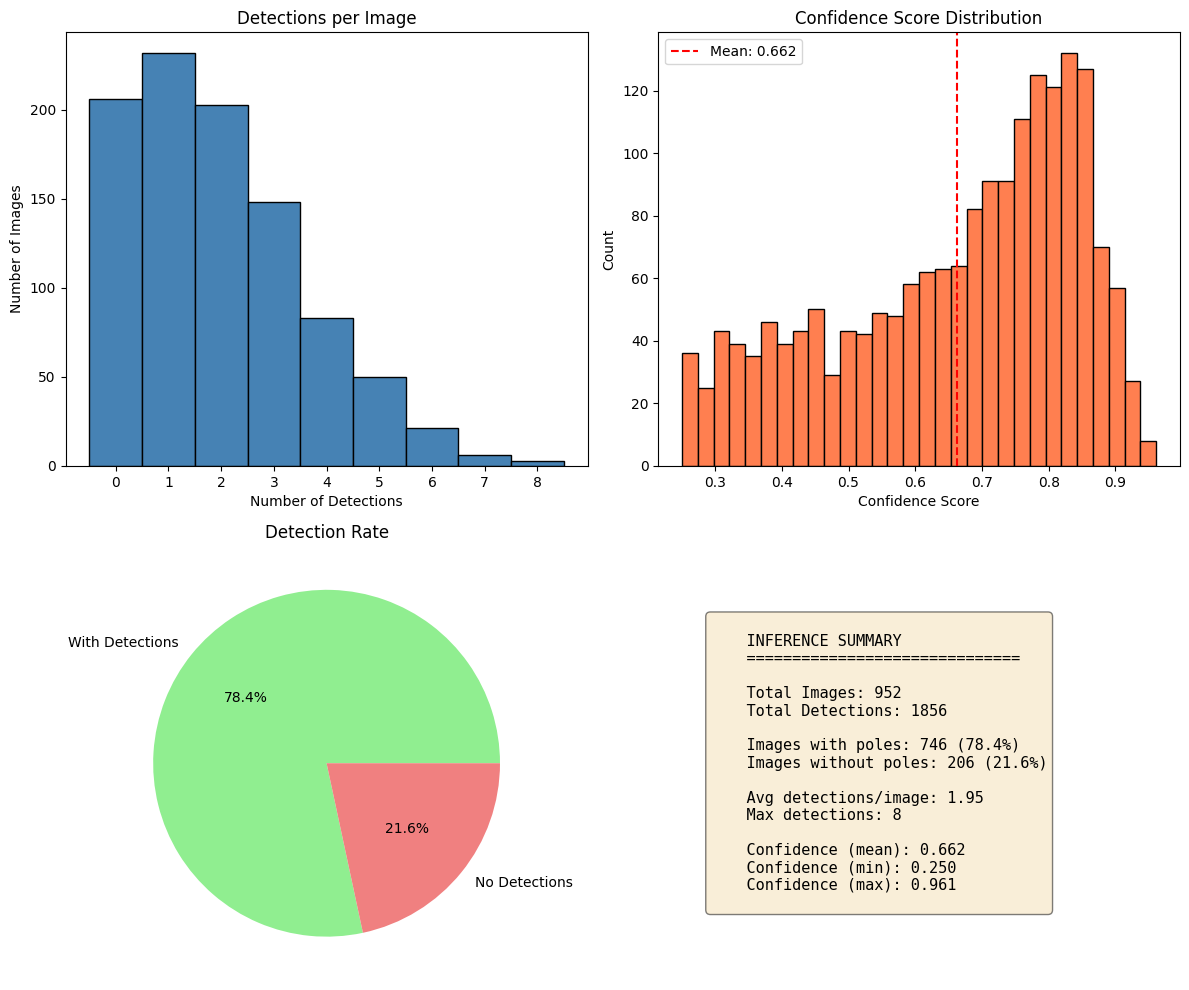

In [15]:
# Detection statistics visualization
def plot_detection_stats(inference_data, output_dir):
    """Create statistical visualizations."""
    if not inference_data:
        print("No inference data!")
        return
    
    detection_counts = inference_data['detection_counts']
    confidences = inference_data['confidences']
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # 1. Detection count distribution
    ax = axes[0, 0]
    max_det = max(detection_counts) if detection_counts else 1
    ax.hist(detection_counts, bins=range(0, max_det + 2), 
            color='steelblue', edgecolor='black', align='left')
    ax.set_xlabel('Number of Detections')
    ax.set_ylabel('Number of Images')
    ax.set_title('Detections per Image')
    ax.set_xticks(range(0, max_det + 1))
    
    # 2. Confidence distribution
    ax = axes[0, 1]
    if confidences:
        ax.hist(confidences, bins=30, color='coral', edgecolor='black')
        ax.axvline(np.mean(confidences), color='red', linestyle='--', 
                   label=f'Mean: {np.mean(confidences):.3f}')
    ax.set_xlabel('Confidence Score')
    ax.set_ylabel('Count')
    ax.set_title('Confidence Score Distribution')
    ax.legend()
    
    # 3. Detection rate pie chart
    ax = axes[1, 0]
    with_det = sum(1 for c in detection_counts if c > 0)
    without_det = sum(1 for c in detection_counts if c == 0)
    ax.pie([with_det, without_det], 
           labels=['With Detections', 'No Detections'],
           autopct='%1.1f%%',
           colors=['lightgreen', 'lightcoral'])
    ax.set_title('Detection Rate')
    
    # 4. Summary stats
    ax = axes[1, 1]
    ax.axis('off')
    
    total_images = len(detection_counts)
    total_detections = sum(detection_counts)
    
    summary_text = f"""
    INFERENCE SUMMARY
    {'='*30}
    
    Total Images: {total_images}
    Total Detections: {total_detections}
    
    Images with poles: {with_det} ({with_det/total_images*100:.1f}%)
    Images without poles: {without_det} ({without_det/total_images*100:.1f}%)
    
    Avg detections/image: {np.mean(detection_counts):.2f}
    Max detections: {max(detection_counts) if detection_counts else 0}
    
    Confidence (mean): {(np.mean(confidences) if confidences else 0):.3f}
    Confidence (min): {(np.min(confidences) if confidences else 0):.3f}
    Confidence (max): {(np.max(confidences) if confidences else 0):.3f}
    """
    
    ax.text(0.1, 0.5, summary_text, transform=ax.transAxes,
            fontsize=11, verticalalignment='center',
            fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    
    # Save
    output_path = output_dir / 'detection_statistics.png'
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved statistics to: {output_path}")
    plt.show()

if inference_data:
    plot_detection_stats(inference_data, OUTPUT_DIR)


Sample Detections
Images with detections: 746
Images without detections: 206

✓ Saved sample detections to: msj_test_results/sample_detections.png


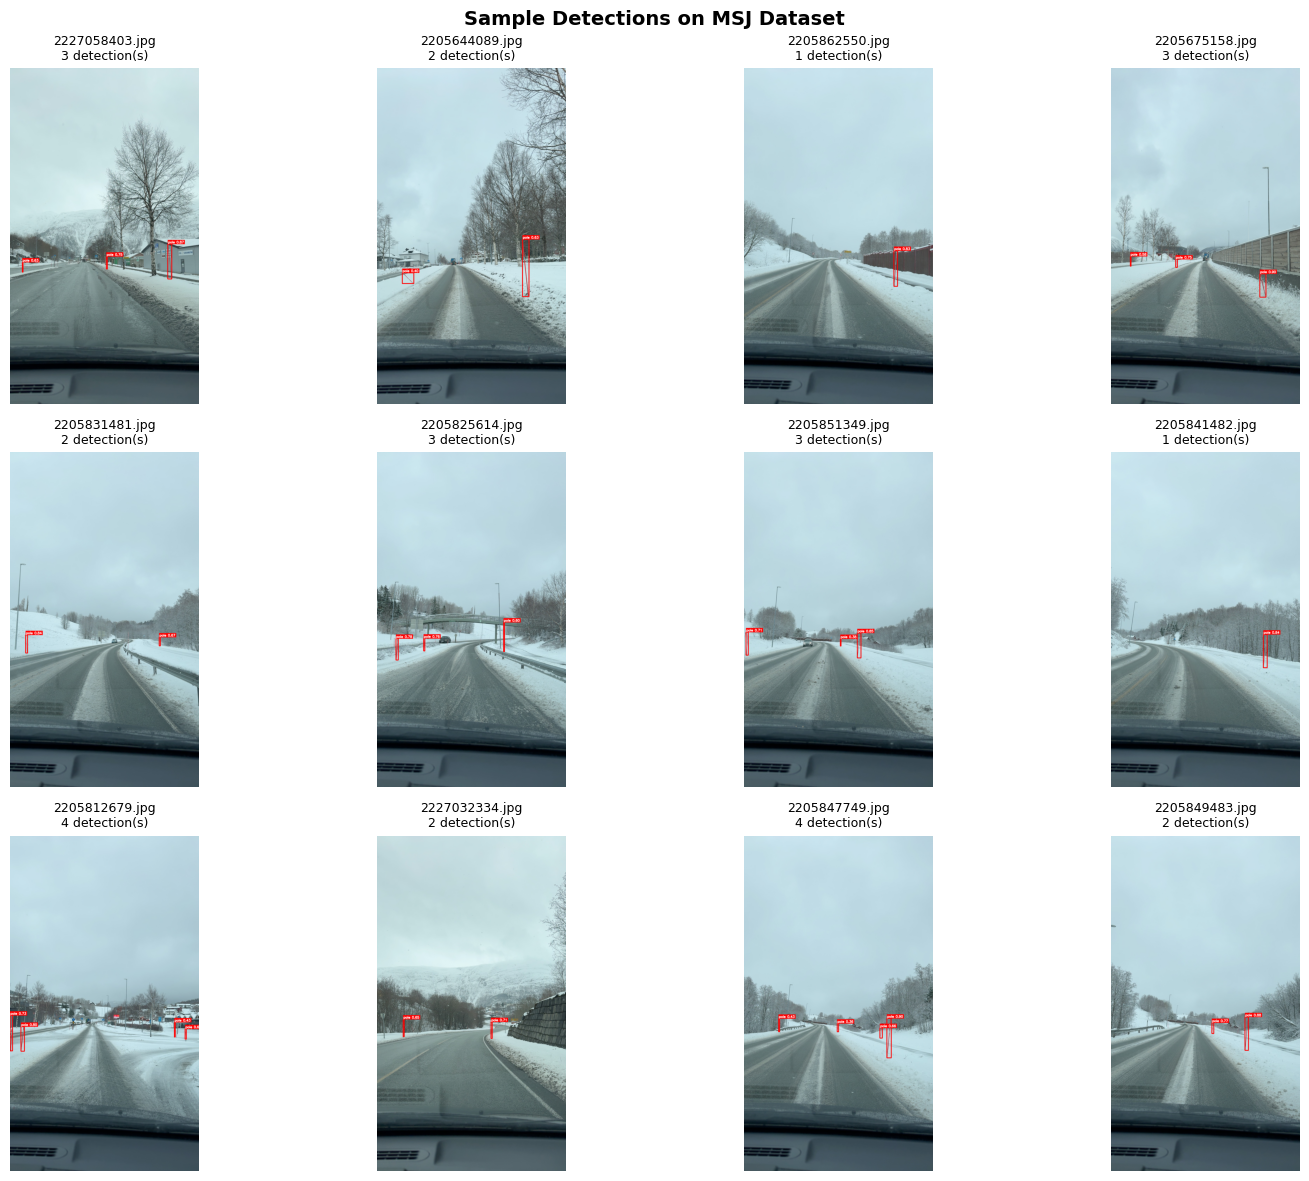

In [16]:
# Visualize sample detections
def visualize_detections(inference_data, num_samples=12, output_dir=None):
    """Visualize sample images with detections."""
    if not inference_data:
        print("No inference data!")
        return
    
    results = inference_data['results']
    
    # Filter images with detections
    with_detections = [r for r in results if r['n_detections'] > 0]
    without_detections = [r for r in results if r['n_detections'] == 0]
    
    print(f"\n{'='*60}")
    print(f"Sample Detections")
    print(f"{'='*60}")
    print(f"Images with detections: {len(with_detections)}")
    print(f"Images without detections: {len(without_detections)}")
    
    # Sample from images with detections
    if with_detections:
        samples = random.sample(with_detections, min(num_samples, len(with_detections)))
    else:
        print("\nNo detections found in any image!")
        samples = random.sample(results, min(num_samples, len(results)))
    
    # Plot
    cols = 4
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
    axes = axes.flatten() if rows > 1 else [axes] if len(samples) == 1 else axes
    
    for idx, sample in enumerate(samples):
        ax = axes[idx]
        
        # Load image
        img = cv2.imread(str(sample['image_path']))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Draw boxes
        for box in sample['boxes']:
            x1, y1, x2, y2 = box['xyxy'].astype(int)
            conf = box['conf']
            
            # Draw rectangle
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
            
            # Draw label
            label = f"pole {conf:.2f}"
            (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(img, (x1, y1-h-10), (x1+w+5, y1), (255, 0, 0), -1)
            cv2.putText(img, label, (x1+2, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 
                       0.6, (255, 255, 255), 2)
        
        ax.imshow(img)
        ax.set_title(f"{sample['image_name']}\n{sample['n_detections']} detection(s)", 
                    fontsize=9)
        ax.axis('off')
    
    # Hide empty subplots
    for idx in range(len(samples), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Sample Detections on MSJ Dataset', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if output_dir:
        output_path = output_dir / 'sample_detections.png'
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"\n✓ Saved sample detections to: {output_path}")
    
    plt.show()

if inference_data:
    visualize_detections(inference_data, num_samples=12, output_dir=OUTPUT_DIR)


Images Without Detections (Potential Misses)

✓ Saved to: msj_test_results/no_detections.png


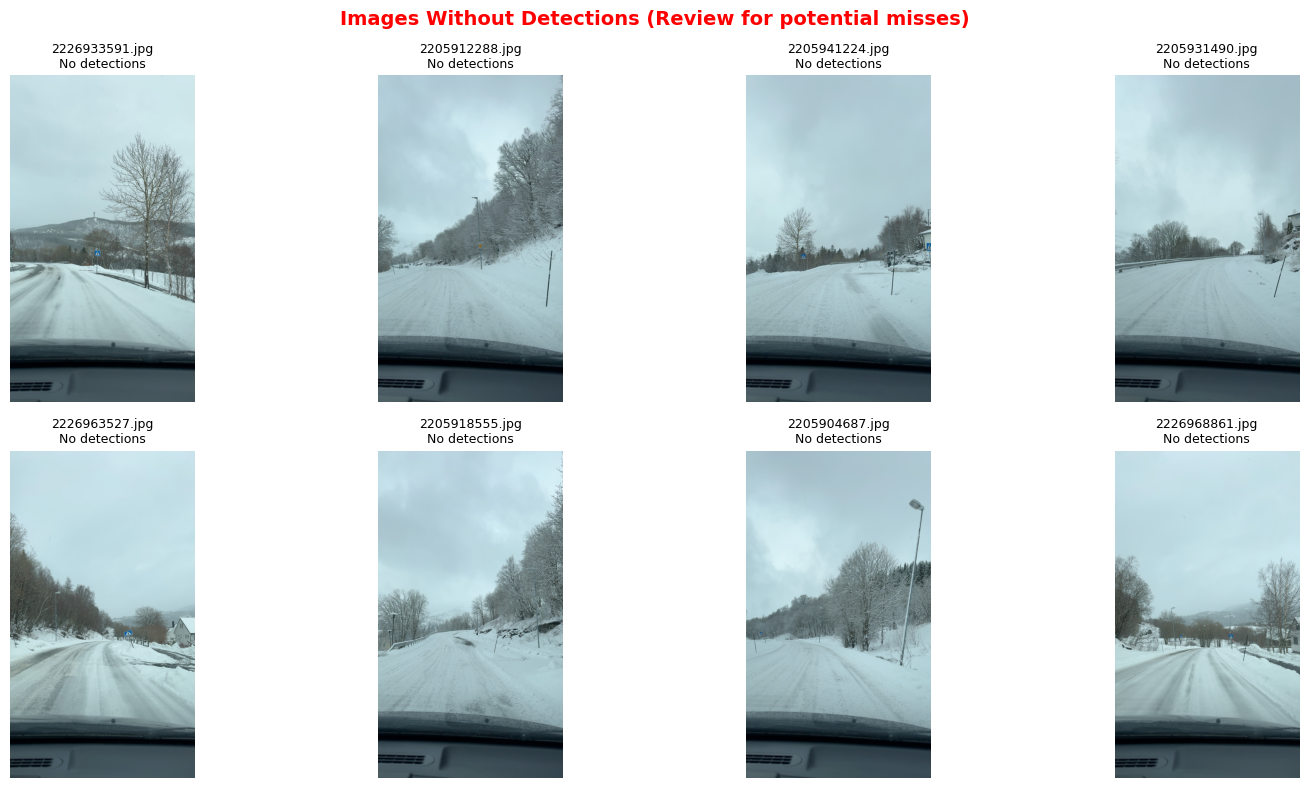

In [17]:
# Show images without detections (potential misses)
def show_no_detection_samples(inference_data, num_samples=8, output_dir=None):
    """Show images where no poles were detected."""
    if not inference_data:
        return
    
    results = inference_data['results']
    no_detections = [r for r in results if r['n_detections'] == 0]
    
    if not no_detections:
        print("All images have detections!")
        return
    
    print(f"\n{'='*60}")
    print(f"Images Without Detections (Potential Misses)")
    print(f"{'='*60}")
    
    samples = random.sample(no_detections, min(num_samples, len(no_detections)))
    
    cols = 4
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
    axes = axes.flatten() if rows > 1 else [axes] if len(samples) == 1 else axes
    
    for idx, sample in enumerate(samples):
        ax = axes[idx]
        img = cv2.imread(str(sample['image_path']))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f"{sample['image_name']}\nNo detections", fontsize=9)
        ax.axis('off')
    
    for idx in range(len(samples), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Images Without Detections (Review for potential misses)', 
                fontsize=14, fontweight='bold', color='red')
    plt.tight_layout()
    
    if output_dir:
        output_path = output_dir / 'no_detections.png'
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"\n✓ Saved to: {output_path}")
    
    plt.show()

if inference_data:
    show_no_detection_samples(inference_data, num_samples=8, output_dir=OUTPUT_DIR)


High Confidence Detections (>= 0.7)
Found 600 images

✓ Saved to: msj_test_results/high_confidence.png


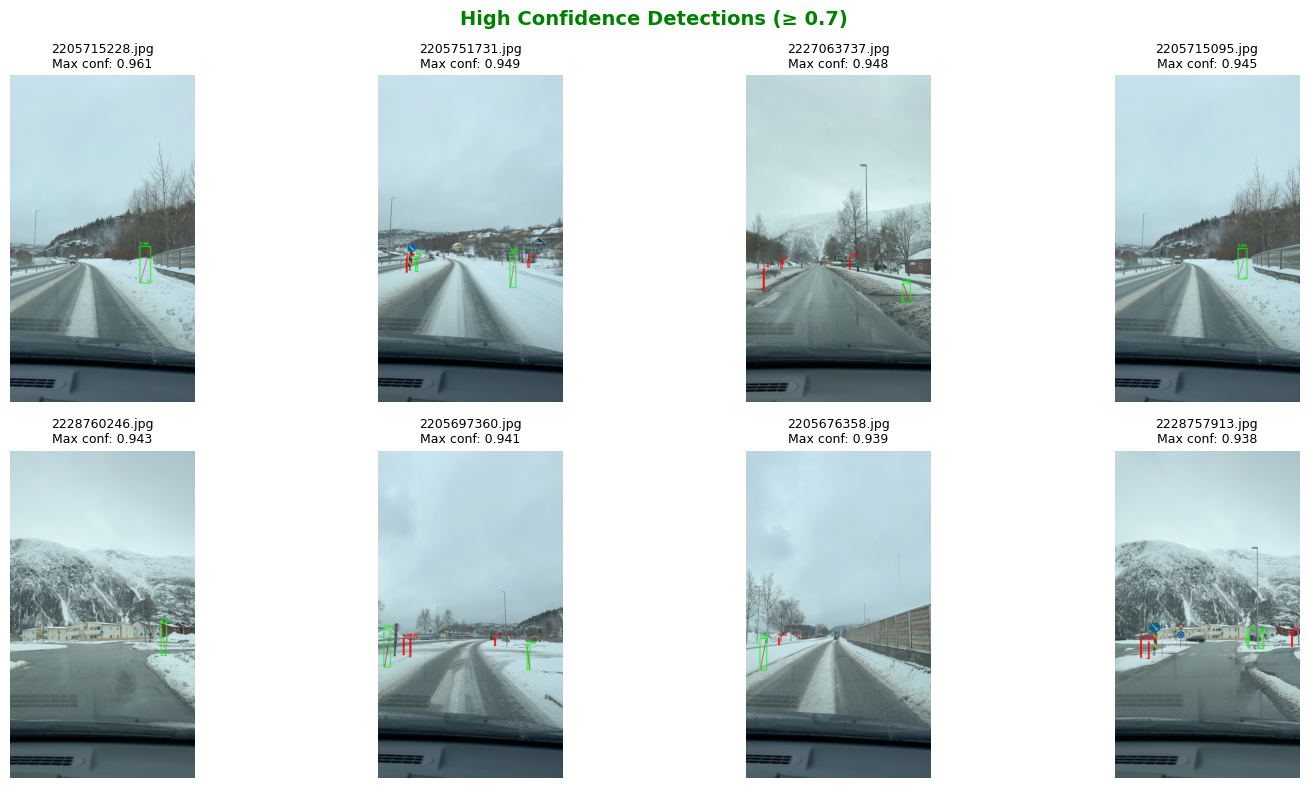

In [18]:
# High confidence detections
def show_high_confidence_detections(inference_data, num_samples=8, min_conf=0.7, output_dir=None):
    """Show detections with high confidence."""
    if not inference_data:
        return
    
    results = inference_data['results']
    
    # Filter for high confidence
    high_conf = []
    for r in results:
        max_conf = max([b['conf'] for b in r['boxes']], default=0)
        if max_conf >= min_conf:
            high_conf.append((r, max_conf))
    
    # Sort by confidence
    high_conf.sort(key=lambda x: x[1], reverse=True)
    
    if not high_conf:
        print(f"No detections with confidence >= {min_conf}")
        return
    
    print(f"\n{'='*60}")
    print(f"High Confidence Detections (>= {min_conf})")
    print(f"{'='*60}")
    print(f"Found {len(high_conf)} images")
    
    samples = high_conf[:num_samples]
    
    cols = 4
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
    axes = axes.flatten() if rows > 1 else [axes] if len(samples) == 1 else axes
    
    for idx, (sample, max_conf) in enumerate(samples):
        ax = axes[idx]
        
        img = cv2.imread(str(sample['image_path']))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        for box in sample['boxes']:
            x1, y1, x2, y2 = box['xyxy'].astype(int)
            conf = box['conf']
            
            color = (0, 255, 0) if conf >= min_conf else (255, 0, 0)
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
            
            label = f"{conf:.2f}"
            cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX,
                       0.7, color, 2)
        
        ax.imshow(img)
        ax.set_title(f"{sample['image_name']}\nMax conf: {max_conf:.3f}", fontsize=9)
        ax.axis('off')
    
    for idx in range(len(samples), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'High Confidence Detections (≥ {min_conf})', 
                fontsize=14, fontweight='bold', color='green')
    plt.tight_layout()
    
    if output_dir:
        output_path = output_dir / 'high_confidence.png'
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"\n✓ Saved to: {output_path}")
    
    plt.show()

if inference_data:
    show_high_confidence_detections(inference_data, num_samples=8, min_conf=0.7, output_dir=OUTPUT_DIR)


Low Confidence Detections (< 0.4) - Review for False Positives
Found 193 images

✓ Saved to: msj_test_results/low_confidence.png


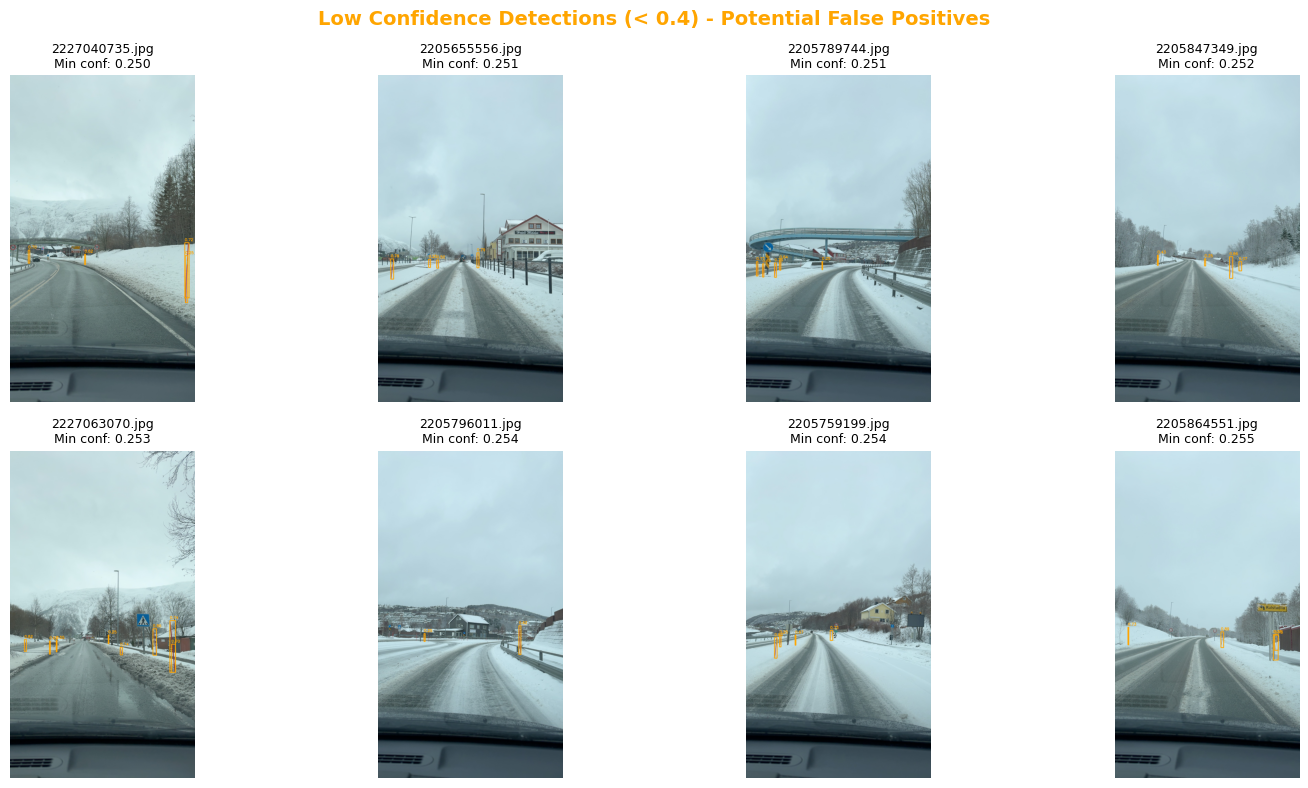

In [19]:
# Low confidence detections (potential false positives)
def show_low_confidence_detections(inference_data, num_samples=8, max_conf=0.4, output_dir=None):
    """Show detections with low confidence (potential false positives)."""
    if not inference_data:
        return
    
    results = inference_data['results']
    
    # Filter for low confidence detections
    low_conf = []
    for r in results:
        if r['n_detections'] > 0:
            min_conf_val = min([b['conf'] for b in r['boxes']])
            if min_conf_val < max_conf:
                low_conf.append((r, min_conf_val))
    
    if not low_conf:
        print(f"No detections with confidence < {max_conf}")
        return
    
    # Sort by confidence (lowest first)
    low_conf.sort(key=lambda x: x[1])
    
    print(f"\n{'='*60}")
    print(f"Low Confidence Detections (< {max_conf}) - Review for False Positives")
    print(f"{'='*60}")
    print(f"Found {len(low_conf)} images")
    
    samples = low_conf[:num_samples]
    
    cols = 4
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
    axes = axes.flatten() if rows > 1 else [axes] if len(samples) == 1 else axes
    
    for idx, (sample, min_conf_val) in enumerate(samples):
        ax = axes[idx]
        
        img = cv2.imread(str(sample['image_path']))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        for box in sample['boxes']:
            x1, y1, x2, y2 = box['xyxy'].astype(int)
            conf = box['conf']
            
            color = (255, 165, 0)  # Orange for low confidence
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
            
            label = f"{conf:.2f}"
            cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX,
                       0.7, color, 2)
        
        ax.imshow(img)
        ax.set_title(f"{sample['image_name']}\nMin conf: {min_conf_val:.3f}", fontsize=9)
        ax.axis('off')
    
    for idx in range(len(samples), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'Low Confidence Detections (< {max_conf}) - Potential False Positives', 
                fontsize=14, fontweight='bold', color='orange')
    plt.tight_layout()
    
    if output_dir:
        output_path = output_dir / 'low_confidence.png'
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"\n✓ Saved to: {output_path}")
    
    plt.show()

if inference_data:
    show_low_confidence_detections(inference_data, num_samples=8, max_conf=0.4, output_dir=OUTPUT_DIR)

## 5. Save All Predictions

In [20]:
# Save predictions to output folder with annotations
def save_all_predictions(model, images, output_dir, conf=0.25, img_size=640):
    """Save all images with predictions overlaid."""
    if not model or not images:
        return
    
    pred_dir = output_dir / 'predictions'
    pred_dir.mkdir(exist_ok=True)
    
    print(f"\n{'='*60}")
    print(f"Saving All Predictions to: {pred_dir}")
    print(f"{'='*60}")
    
    for img_path in tqdm(images, desc="Saving predictions"):
        try:
            results = model.predict(
                source=str(img_path),
                conf=conf,
                imgsz=img_size,
                verbose=False
            )
            
            # Get annotated image
            result = results[0]
            annotated = result.plot()  # RGB with annotations
            
            # Save
            output_path = pred_dir / img_path.name
            cv2.imwrite(str(output_path), cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR))
            
        except Exception as e:
            print(f"Error with {img_path.name}: {e}")
    
    print(f"\n✓ Saved {len(images)} annotated images to: {pred_dir}")

# Uncomment to save all predictions (may take time for large datasets)
if model and msj_images:
    save_all_predictions(model, msj_images, OUTPUT_DIR, conf=CONF_THRESHOLD)


Saving All Predictions to: msj_test_results/predictions


Saving predictions: 100%|██████████| 952/952 [00:17<00:00, 55.94it/s]


✓ Saved 952 annotated images to: msj_test_results/predictions


## 6. Export Results

In [21]:
# Export results to CSV and JSON
def export_results(inference_data, output_dir):
    """Export detection results to CSV and JSON."""
    if not inference_data:
        return
    
    results = inference_data['results']
    
    # Create DataFrame
    rows = []
    for r in results:
        for i, box in enumerate(r['boxes']):
            rows.append({
                'image': r['image_name'],
                'detection_id': i,
                'confidence': box['conf'],
                'x1': box['xyxy'][0],
                'y1': box['xyxy'][1],
                'x2': box['xyxy'][2],
                'y2': box['xyxy'][3],
            })
        
        # Add row for images without detections
        if r['n_detections'] == 0:
            rows.append({
                'image': r['image_name'],
                'detection_id': None,
                'confidence': None,
                'x1': None,
                'y1': None,
                'x2': None,
                'y2': None,
            })
    
    df = pd.DataFrame(rows)
    
    # Save CSV
    csv_path = output_dir / 'msj_detections.csv'
    df.to_csv(csv_path, index=False)
    print(f"✓ Saved CSV: {csv_path}")
    
    # Save JSON summary
    summary = {
        'dataset': 'MSJ',
        'model': str(MODEL_PATH),
        'timestamp': datetime.now().isoformat(),
        'config': {
            'conf_threshold': CONF_THRESHOLD,
            'iou_threshold': IOU_THRESHOLD,
            'img_size': IMG_SIZE
        },
        'statistics': {
            'total_images': len(results),
            'total_detections': sum(inference_data['detection_counts']),
            'images_with_detections': sum(1 for c in inference_data['detection_counts'] if c > 0),
            'images_without_detections': sum(1 for c in inference_data['detection_counts'] if c == 0),
            'avg_detections_per_image': float(np.mean(inference_data['detection_counts'])),
            'avg_confidence': float(np.mean(inference_data['confidences'])) if inference_data['confidences'] else 0,
            'min_confidence': float(min(inference_data['confidences'])) if inference_data['confidences'] else 0,
            'max_confidence': float(max(inference_data['confidences'])) if inference_data['confidences'] else 0,
        }
    }
    
    json_path = output_dir / 'msj_results_summary.json'
    with open(json_path, 'w') as f:
        json.dump(summary, f, indent=2)
    print(f"✓ Saved JSON: {json_path}")
    
    return df

if inference_data:
    results_df = export_results(inference_data, OUTPUT_DIR)
    print("\nResults preview:")
    display(results_df.head(10))

✓ Saved CSV: msj_test_results/msj_detections.csv
✓ Saved JSON: msj_test_results/msj_results_summary.json

Results preview:


,image,detection_id,confidence,x1,y1,x2,y2
0,2205540534.jpg,0.0,0.834237,61.655560,1042.156006,78.142525,1220.657349
1,2205540934.jpg,NaN,NaN,NaN,NaN,NaN,NaN
2,2205553735.jpg,NaN,NaN,NaN,NaN,NaN,NaN
3,2205553868.jpg,NaN,NaN,NaN,NaN,NaN,NaN
4,2205554669.jpg,NaN,NaN,NaN,NaN,NaN,NaN
5,2205555602.jpg,NaN,NaN,NaN,NaN,NaN,NaN
6,2205559736.jpg,0.0,0.343265,771.433960,771.927612,797.297607,1065.904175
7,2205559869.jpg,0.0,0.561281,787.467957,757.839966,813.195190,1056.725220
8,2205560002.jpg,NaN,NaN,NaN,NaN,NaN,NaN
9,2205567736.jpg,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Summary

In [22]:
print(f"\n{'='*60}")
print("MSJ DATASET TESTING COMPLETE")
print(f"{'='*60}")

if inference_data:
    dc = inference_data['detection_counts']
    conf = inference_data['confidences']
    
    print(f"""
Model: {MODEL_PATH.name if MODEL_PATH else 'N/A'}
Dataset: MSJ ({len(dc)} images)

RESULTS:
  Total detections: {sum(dc)}
  Detection rate: {sum(1 for c in dc if c > 0) / len(dc) * 100:.1f}%
  Avg detections/image: {np.mean(dc):.2f}
  Avg confidence: {(np.mean(conf) if conf else 0):.3f}

OUTPUT FILES:
  - {OUTPUT_DIR}/detection_statistics.png
  - {OUTPUT_DIR}/sample_detections.png
  - {OUTPUT_DIR}/no_detections.png
  - {OUTPUT_DIR}/high_confidence.png
  - {OUTPUT_DIR}/low_confidence.png
  - {OUTPUT_DIR}/msj_detections.csv
  - {OUTPUT_DIR}/msj_results_summary.json
    """)
else:
    print("\n⚠️ No inference results available!")
    print("Please check:")
    print("  1. Model path is correct")
    print("  2. MSJ dataset path is correct")

print(f"{'='*60}")


MSJ DATASET TESTING COMPLETE

Model: best.pt
Dataset: MSJ (952 images)

RESULTS:
  Total detections: 1856
  Detection rate: 78.4%
  Avg detections/image: 1.95
  Avg confidence: 0.662

OUTPUT FILES:
  - msj_test_results/detection_statistics.png
  - msj_test_results/sample_detections.png
  - msj_test_results/no_detections.png
  - msj_test_results/high_confidence.png
  - msj_test_results/low_confidence.png
  - msj_test_results/msj_detections.csv
  - msj_test_results/msj_results_summary.json
    
